In [40]:
!nvidia-smi


Mon Apr  6 11:54:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...    Off |   00000000:64:00.0  On |                  N/A |
| N/A   55C    P8              4W /   50W |    6818MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
# --- cell 2 --- TOUJOURS EN PREMIER avant tout import jax
import os, sys
sys.path.append("../../")

# GPU config — DOIT être avant import jax
os.environ['CUDA_DEVICE_ORDER']              = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES']           = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']  = 'false'   # ← clé manquante
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.7'     # limite à 70% VRAM

import jax
import jax.numpy as jnp

jax.config.update('jax_disable_jit', False)
jax.config.update('jax_debug_nans', False)

print("Backend :", jax.default_backend())
print("Devices :", jax.devices())

Backend : cpu
Devices : [CpuDevice(id=0)]


In [42]:
import diffhydro as dh


eq = dh.equationmanager.EquationManager()
eq.mesh_shape=[150,150,150]

In [43]:
U = dh.turbulence.init_turbulent_velocity(eq, 100, 1.0, 1.0,kmax=10,seed=123)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


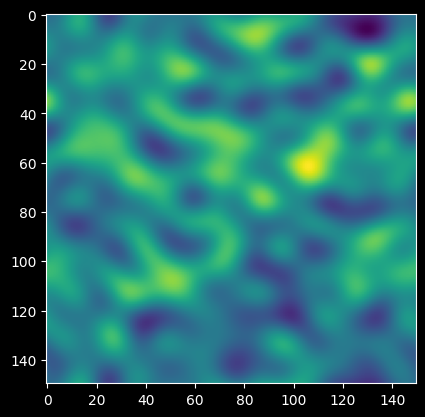

In [44]:
%pylab inline
imshow(U[3][30])

In [45]:
eq.cfl = 0.3
ss = dh.signal_speed_Rusanov

solver = dh.LaxFriedrichs(equation_manager=eq,signal_speed=ss)
grav = dh.physics.gravity.FFTSelfGravityForce(eq, G=6E-4, subtract_mean=True)  

cf = dh.ConvectiveFlux(eq,solver,dh.MUSCL3(limiter="VANLEER"),positivity=False)
#ct = dh.mhd.ConstrainedTransportFlux(eq, solver, dh.MUSCL3(limiter="MINMOD"), positivity=False)

hydro = dh.hydro(n_super_step=2000, fluxes=[cf],forces=[grav],
                 use_mol=True, integrator="RK2",
                 snapshot_every=50,snapshot_dir="turb_collapse_big2",pmesh_shape=(1,1,1)) 
                 
                 

In [46]:
import copy
params = {}
output = hydro.evolve_with_callbacks(copy.deepcopy(U),params)

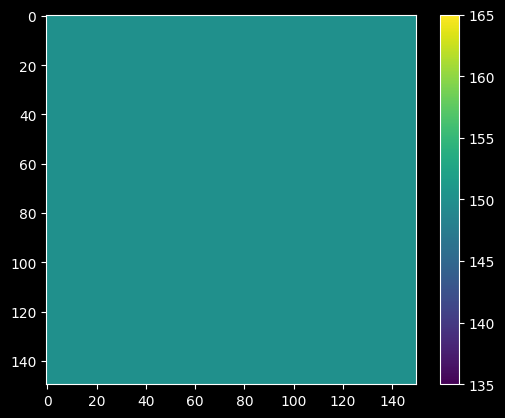

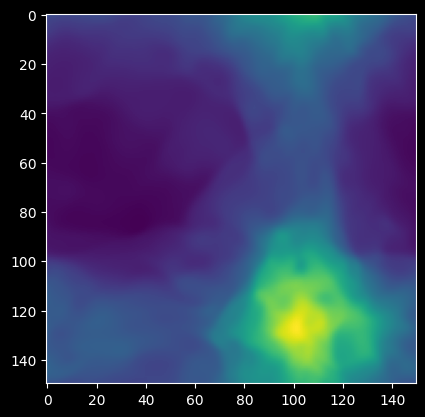

In [47]:
imshow(U[0].sum(axis=0))
colorbar()
show()
imshow(output[0][0][30])
show()

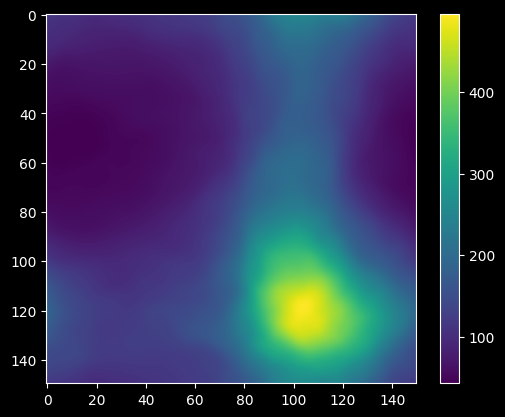

In [48]:
imshow(output[0][0].sum(axis=0))
colorbar()

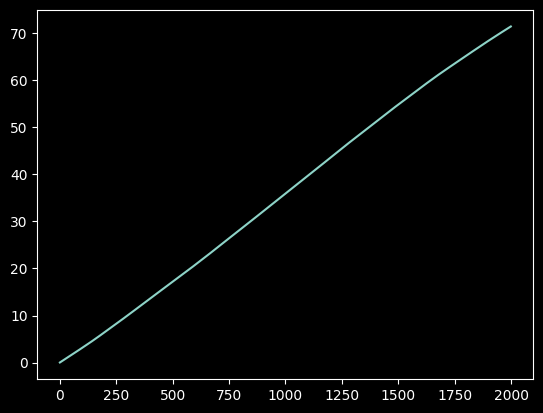

In [49]:
plt.plot(np.cumsum(output[-1]))

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


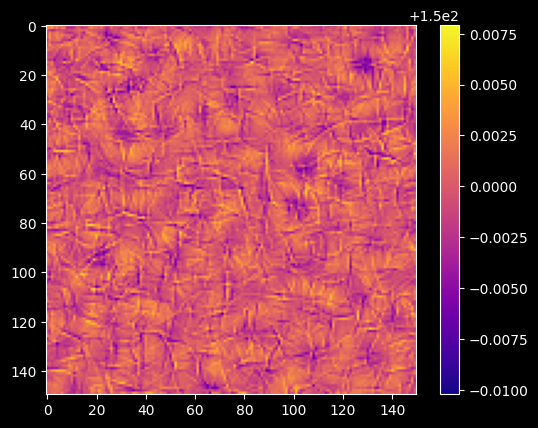

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


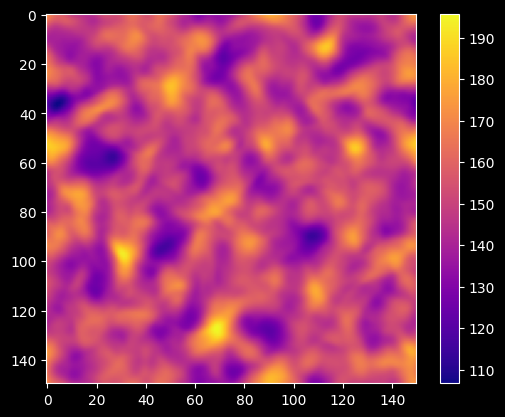

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


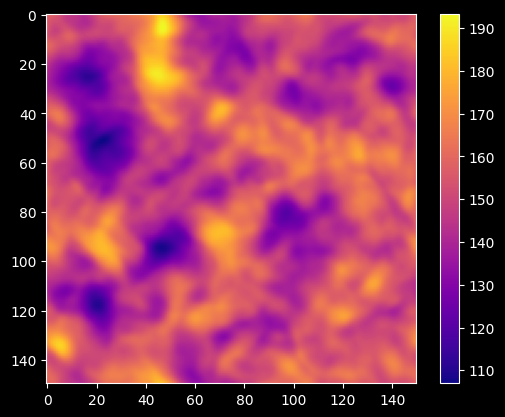

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


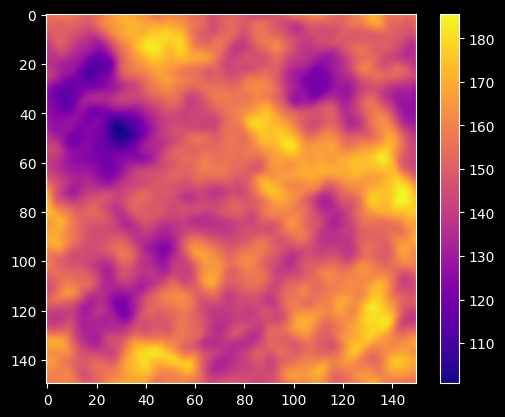

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


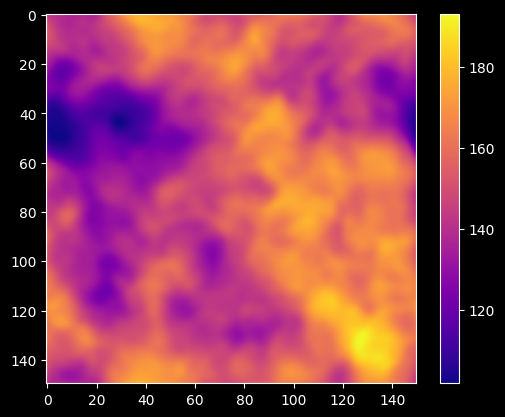

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


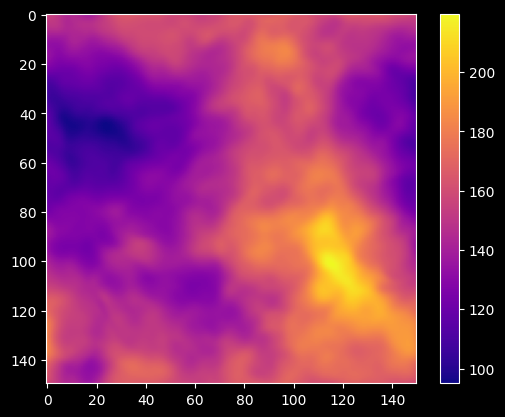

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


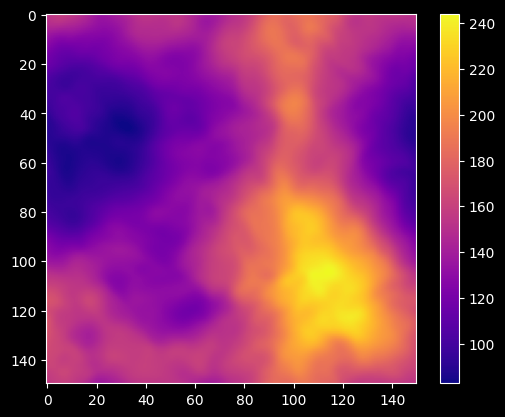

Shard shape: (5, 150, 150, 150)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


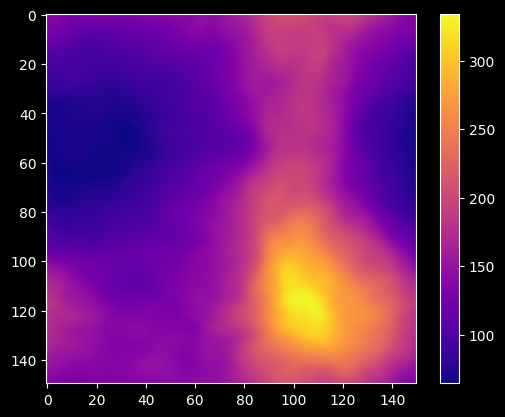

FileNotFoundError: [Errno 2] No such file or directory: 'turb_collapse_big2/fields_step_002000_device_0.npy'

In [50]:
from diffhydro.utils.io import shard_snaps

for i in range(0,5000,250):
    imshow(shard_snaps.load_snapshot(hydro,i)[0].sum(axis=0),cmap="plasma")
    colorbar()
    show()

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


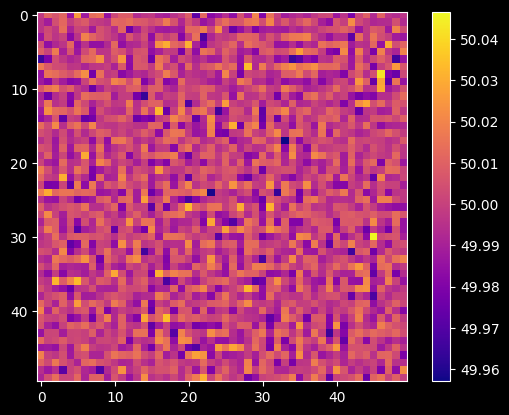

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


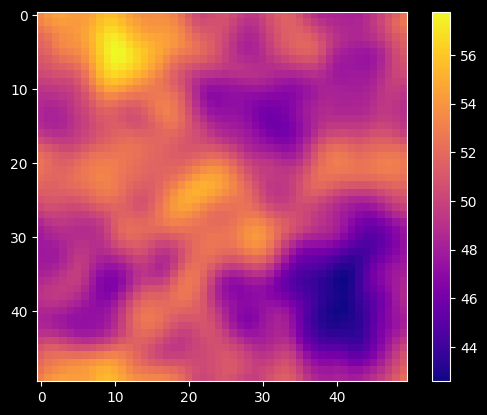

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


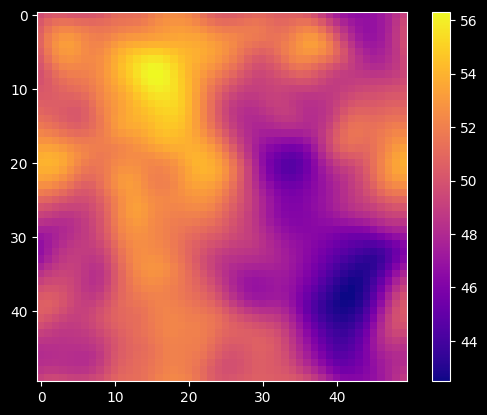

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


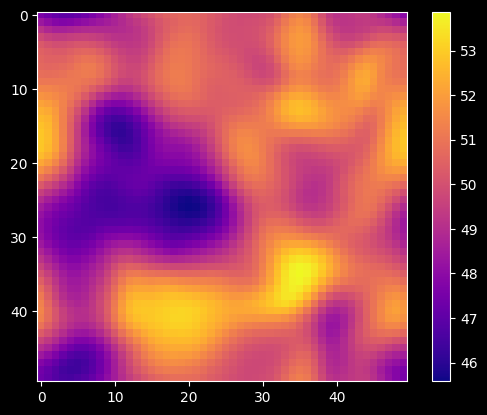

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


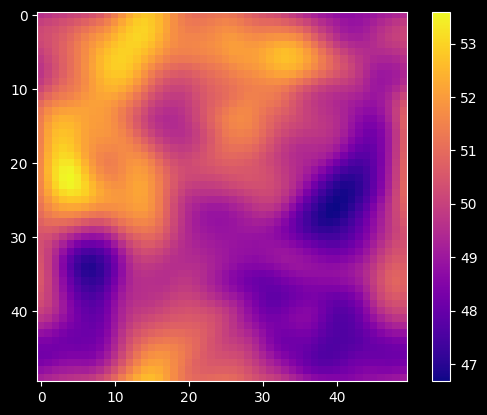

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


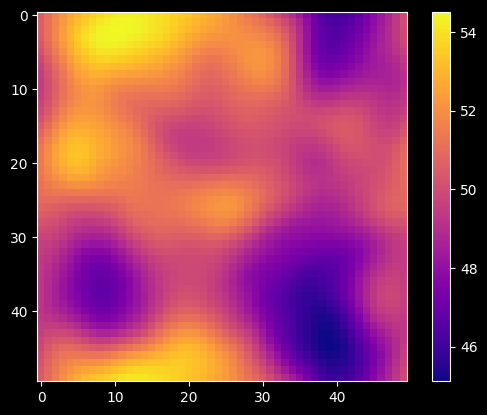

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


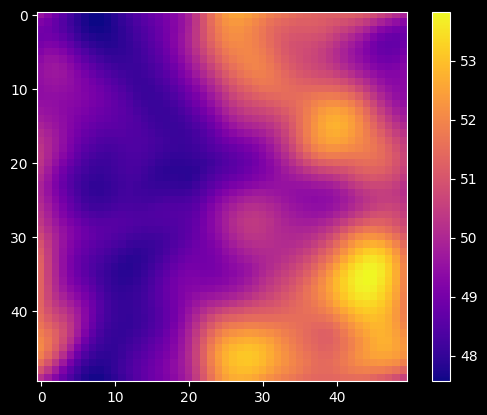

Shard shape: (5, 50, 50, 50)
Partition spec: P(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


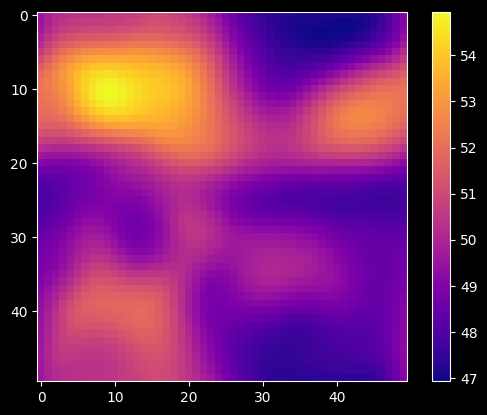

FileNotFoundError: [Errno 2] No such file or directory: 'turb_collapse_big2/fields_step_002000_device_0.npy'

In [ ]:
from diffhydro.utils.io import shard_snaps

for i in range(0,5000,250):
    imshow(shard_snaps.load_snapshot(hydro,i)[0].sum(axis=2),cmap="plasma")
    colorbar()
    show()

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


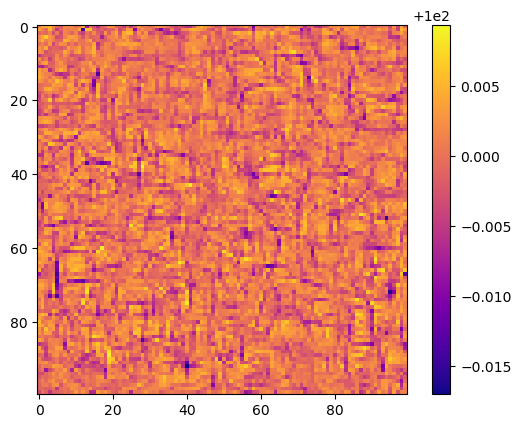

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


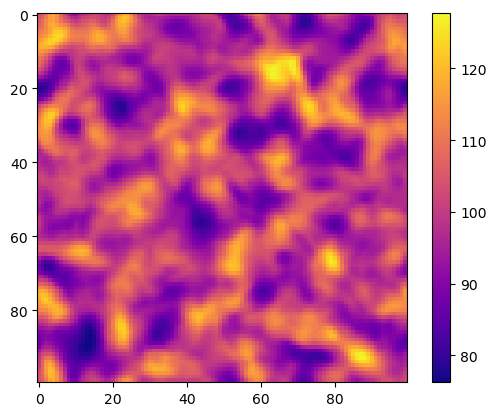

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


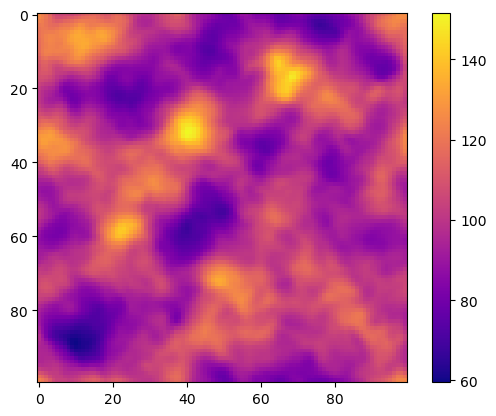

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


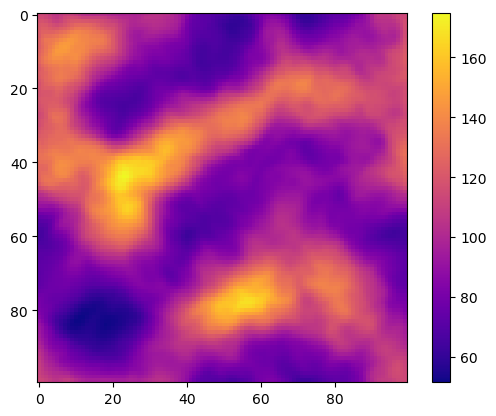

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


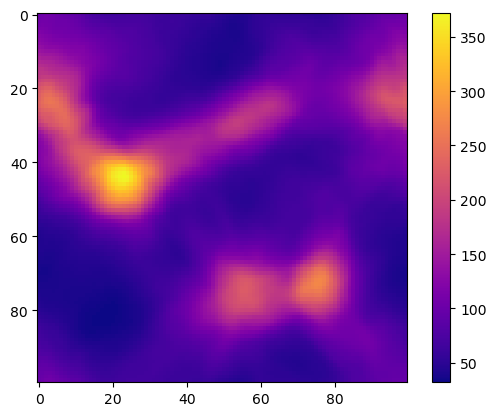

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


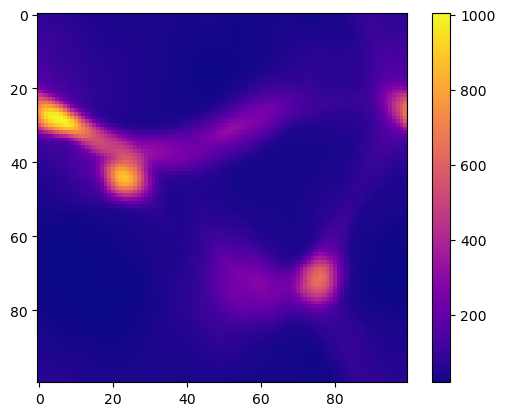

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


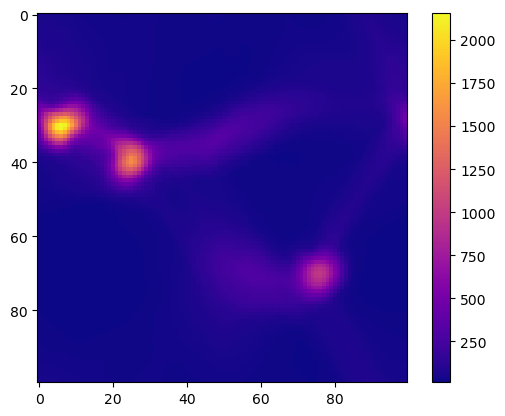

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


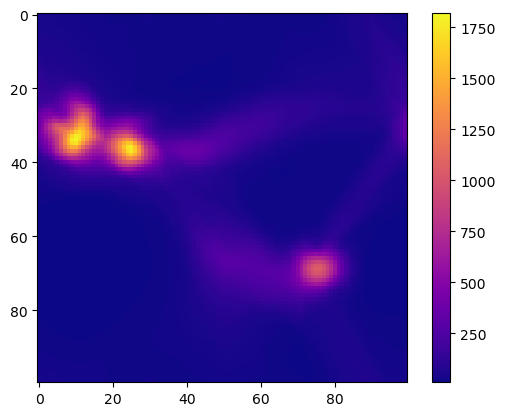

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


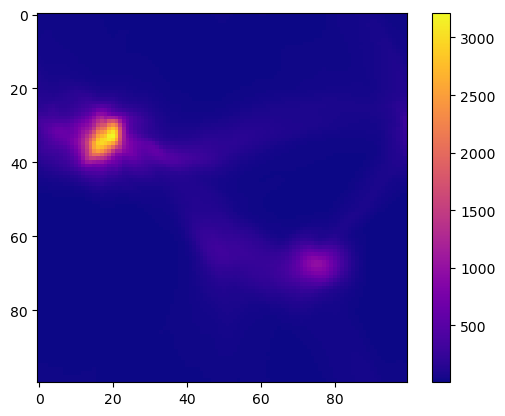

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


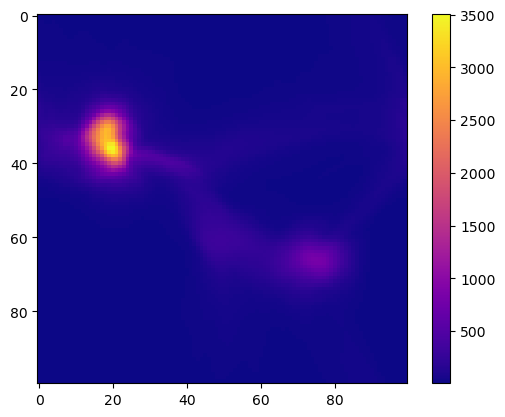

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


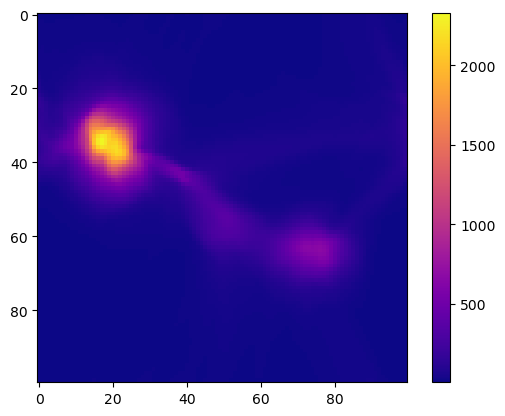

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


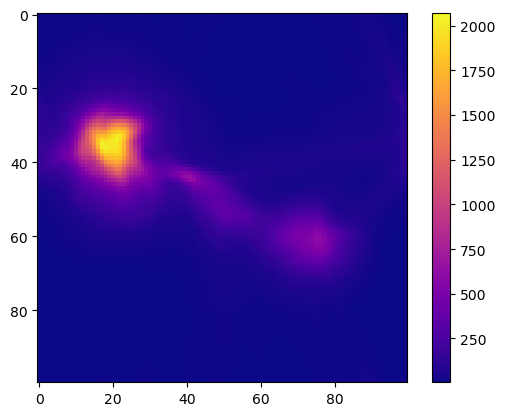

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


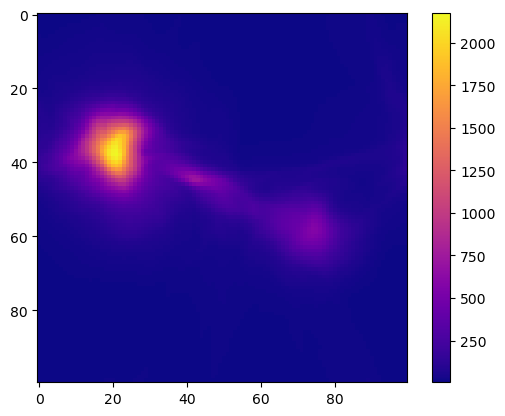

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


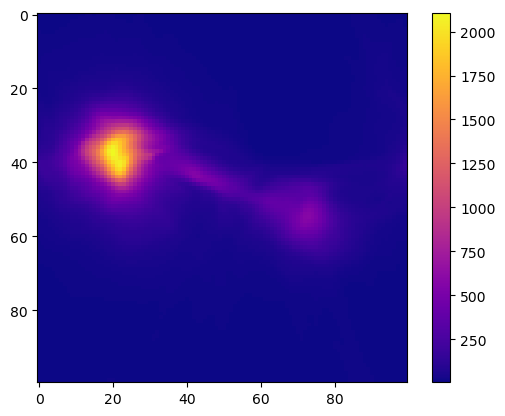

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


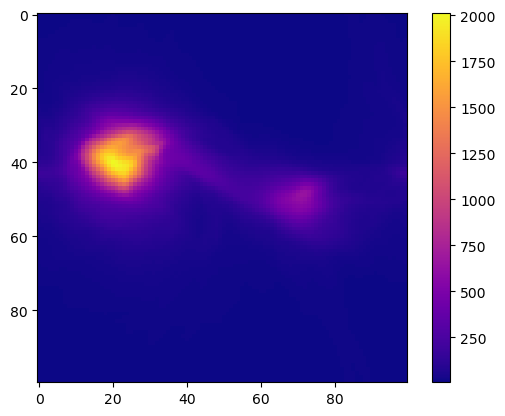

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


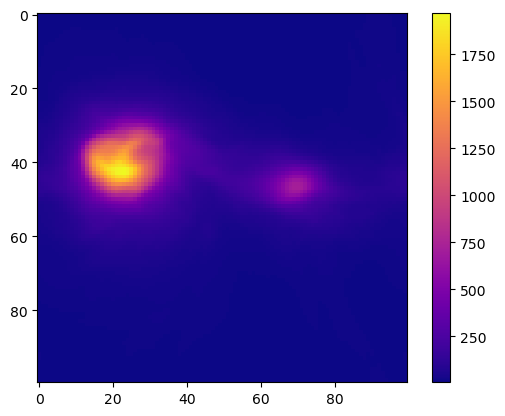

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


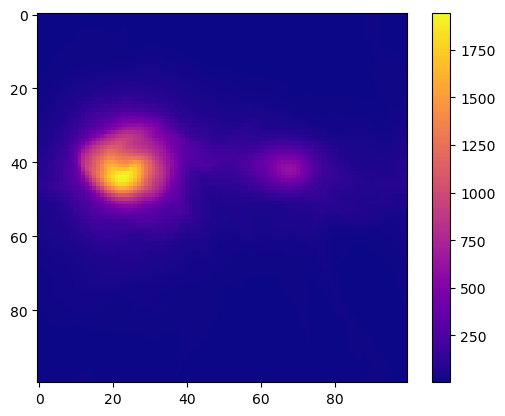

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


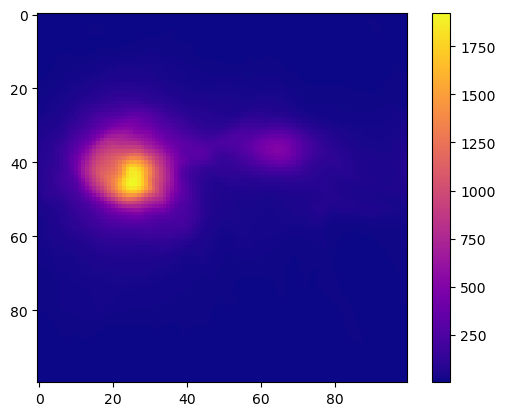

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


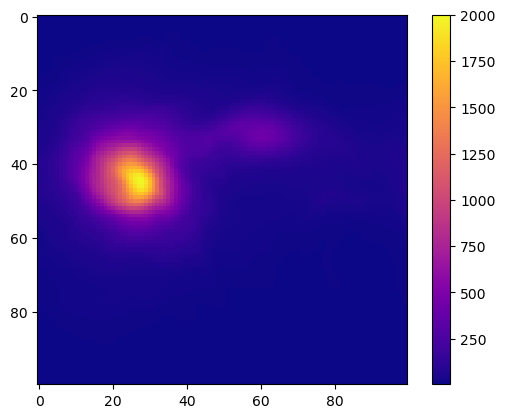

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


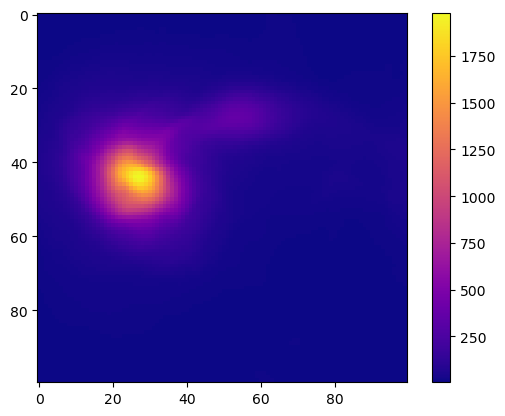

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


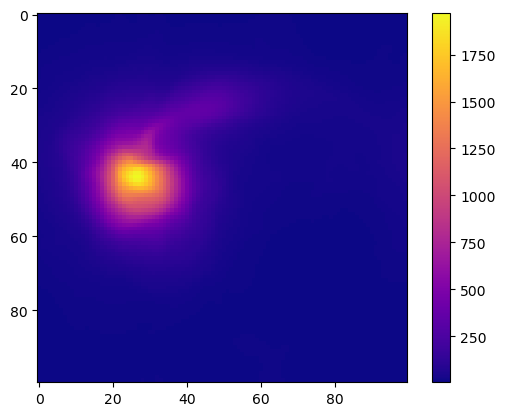

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


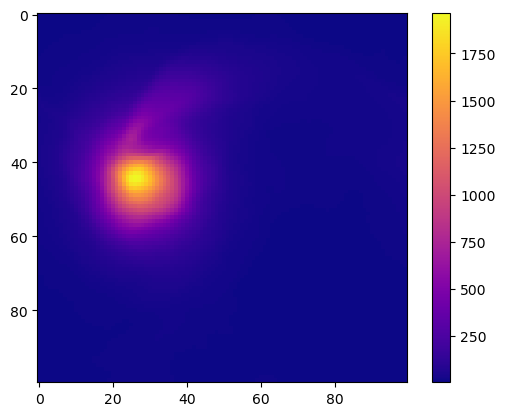

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


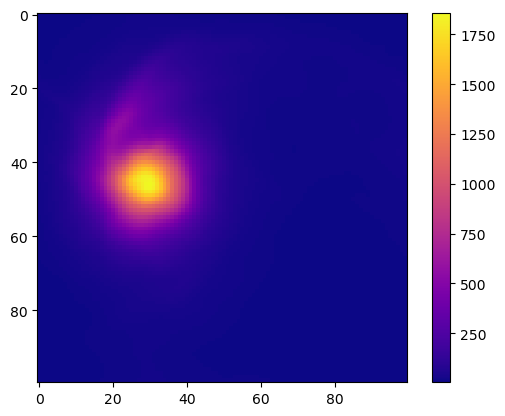

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


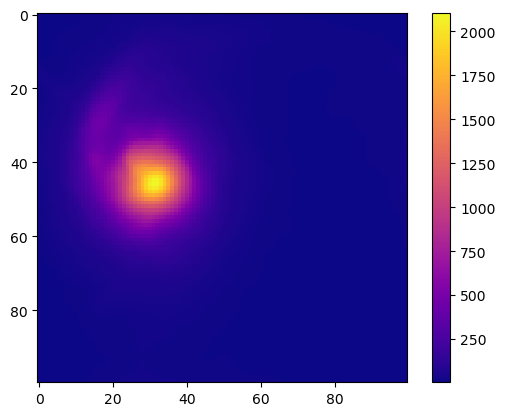

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


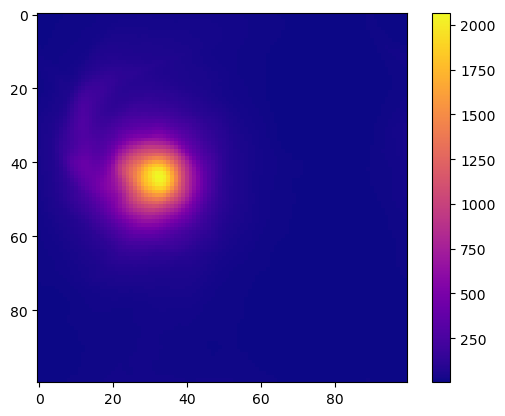

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


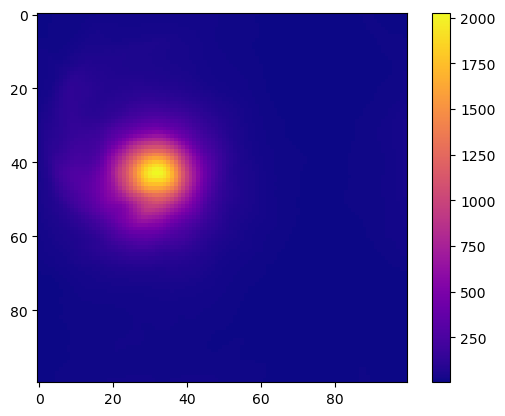

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


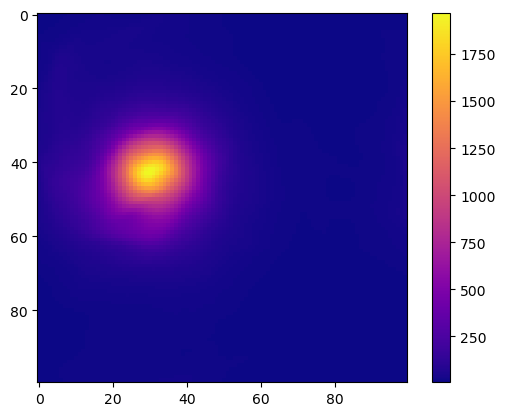

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


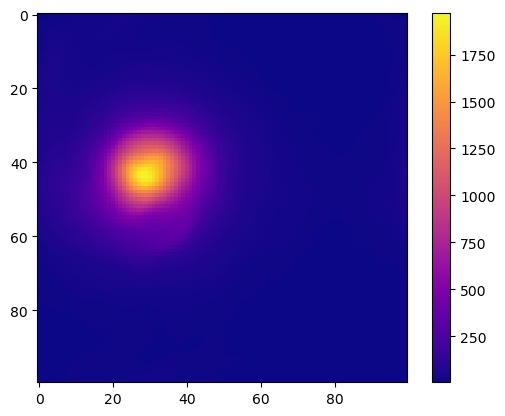

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


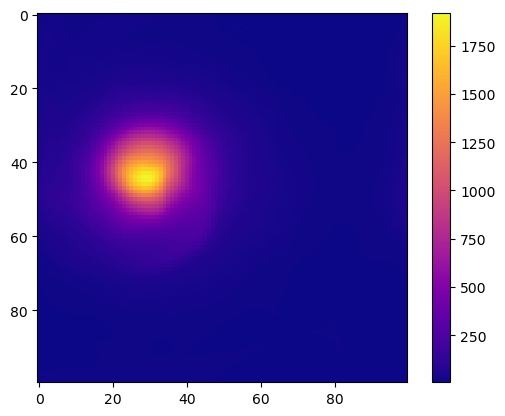

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


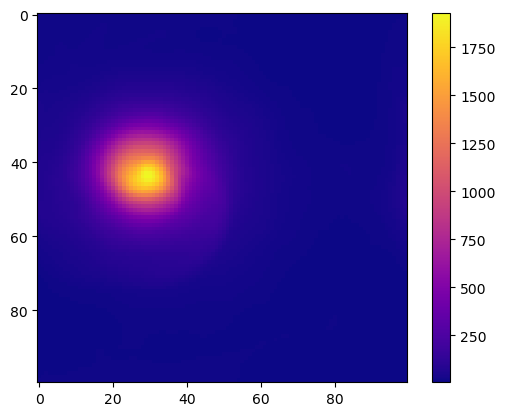

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


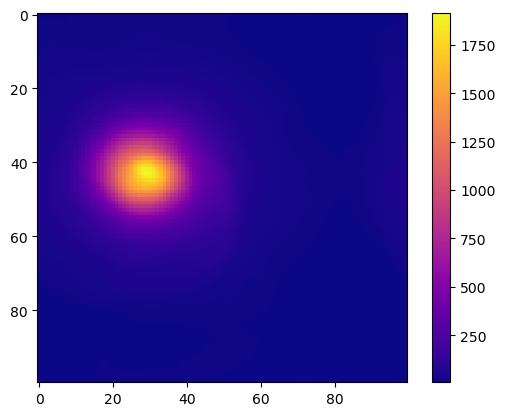

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


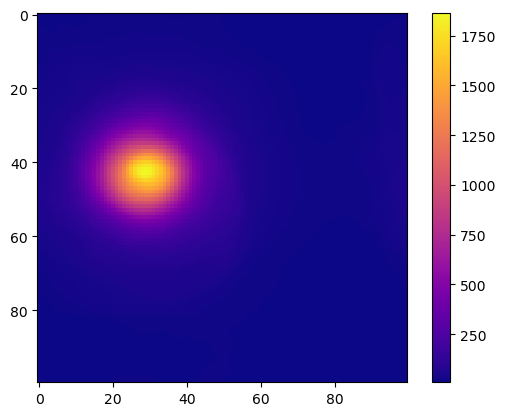

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


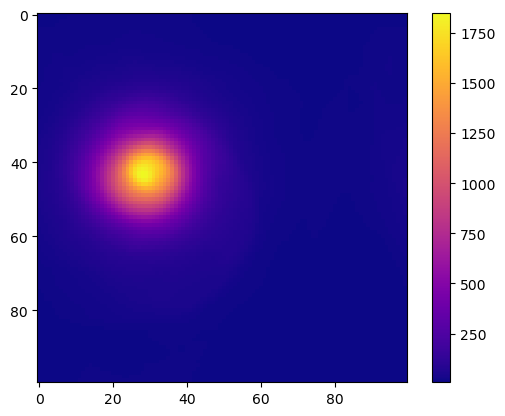

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


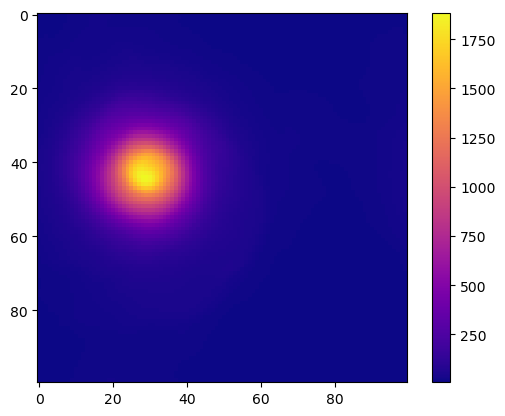

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


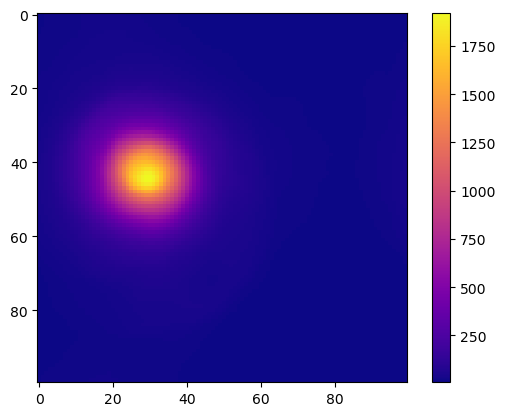

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


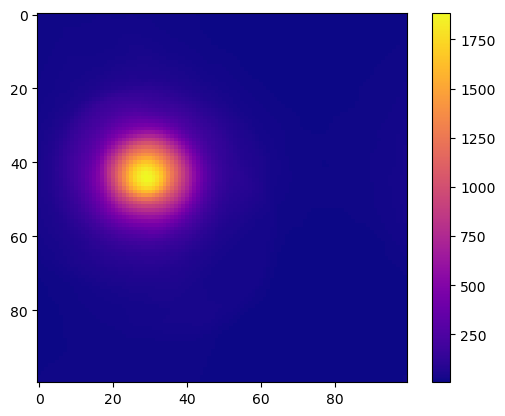

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


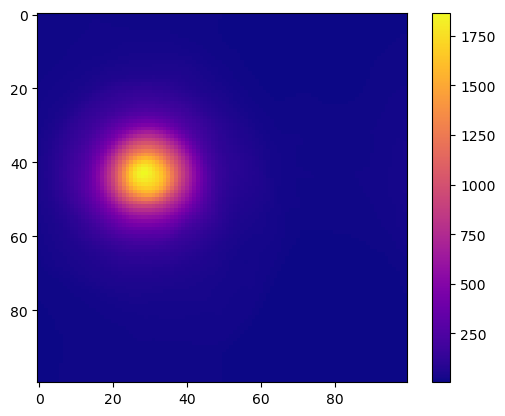

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


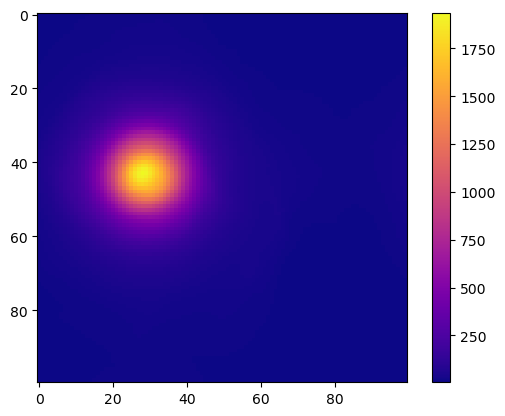

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


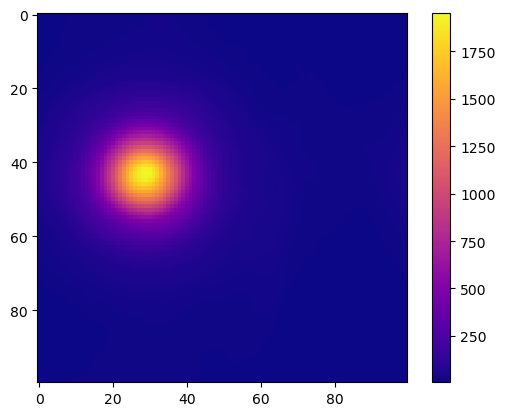

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


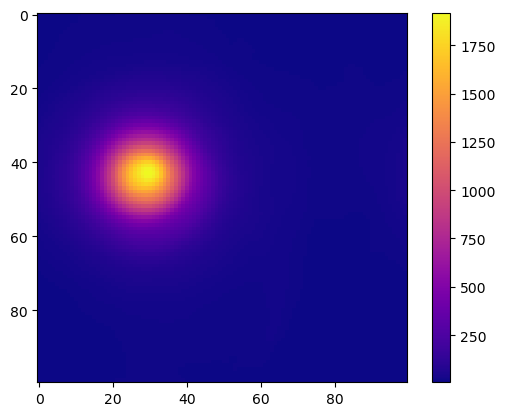

In [ ]:
from diffhydro.utils.io import shard_snaps

for i in range(0,10000,250):
    imshow(shard_snaps.load_snapshot(hydro,i)[0].sum(axis=2),cmap="plasma")
    colorbar()
    show()

In [ ]:
#pretty cute looking! Nice mergers/accretion, stablish blob afterward...

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


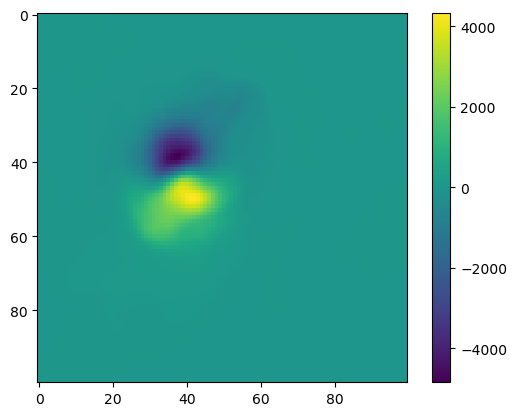

In [ ]:
#velocity info
imshow(shard_snaps.load_snapshot(hydro,i)[-3].sum(axis=1))
colorbar()
show()

Shard shape: (5, 100, 100, 100)
Partition spec: PartitionSpec(None, 'x', 'y', 'z')
Axis mapping: {'x': 1, 'y': 2, 'z': 3}


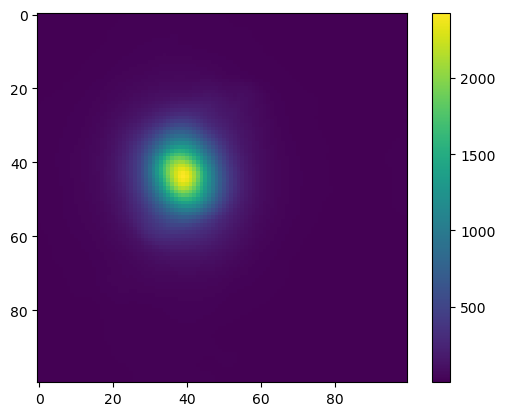

In [ ]:
imshow(shard_snaps.load_snapshot(hydro,i)[0].sum(axis=1))
colorbar()
show()